<a href="https://colab.research.google.com/github/vaibhavkatex/Machine-Learning/blob/main/S20op.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
Uploaded = files.upload()

Saving CAR DETAILS FROM CAR DEKHO.csv to CAR DETAILS FROM CAR DEKHO.csv


In [3]:
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

**EDA**

In [4]:
df.shape

(4340, 8)

In [5]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [10]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [11]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [13]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [15]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


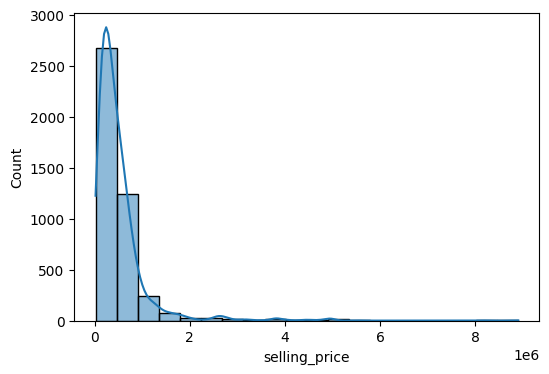

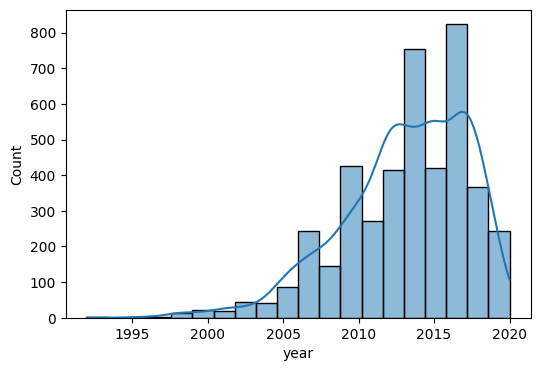

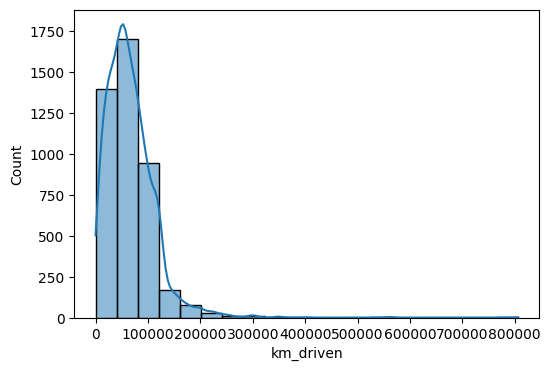

In [29]:
numeric_columns = ["selling_price","year","km_driven"]
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True,bins=20)

<Axes: xlabel='count', ylabel='fuel'>

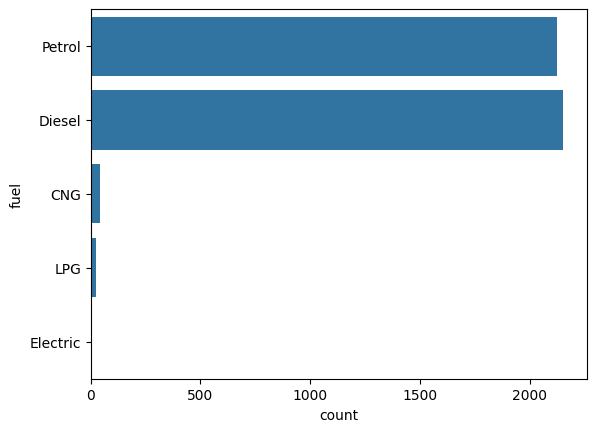

In [32]:
sns.countplot(df['fuel'])

<Axes: xlabel='count', ylabel='transmission'>

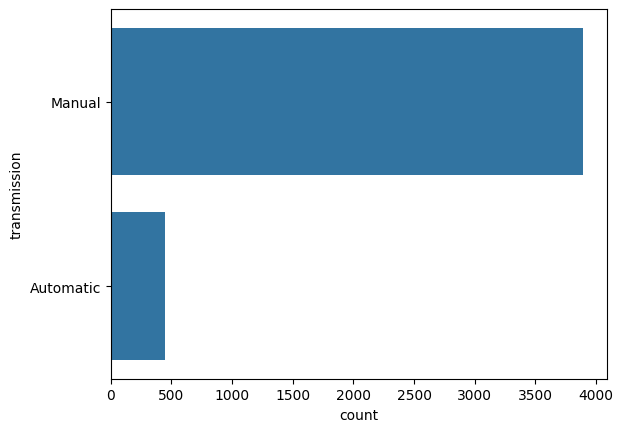

In [33]:
sns.countplot(df['transmission'])

<Axes: xlabel='count', ylabel='seller_type'>

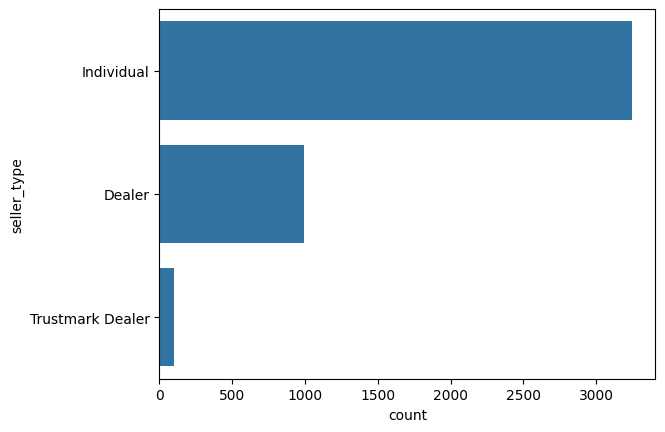

In [34]:
sns.countplot(df["seller_type"])

<Axes: xlabel='count', ylabel='owner'>

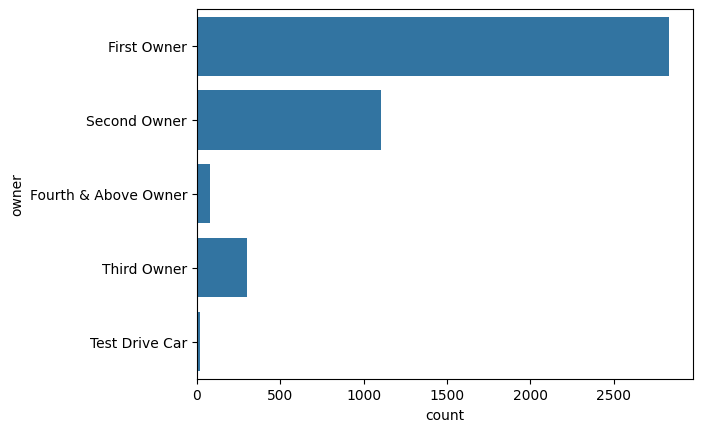

In [35]:
sns.countplot(df["owner"])

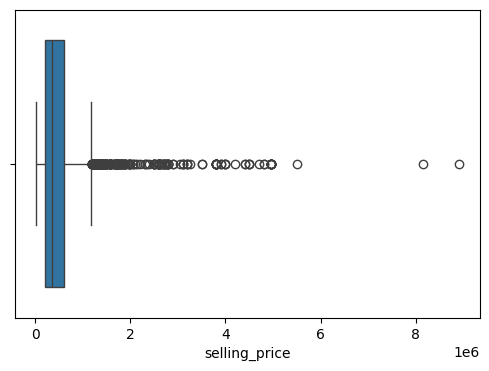

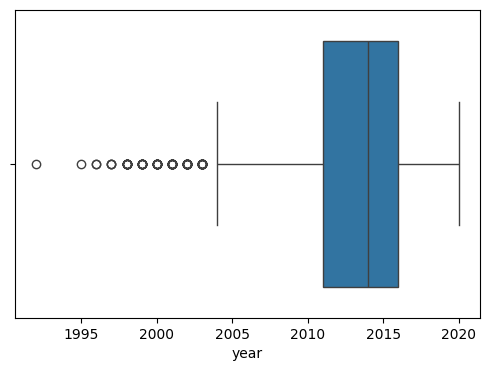

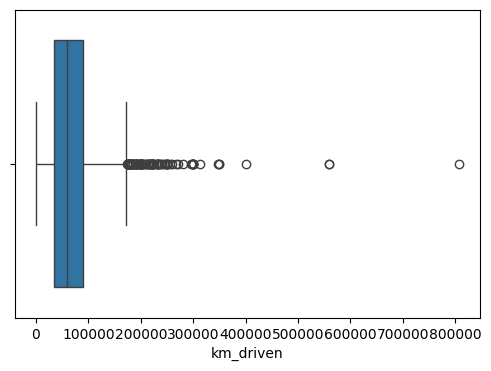

In [39]:
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(x = df[col])

<Axes: >

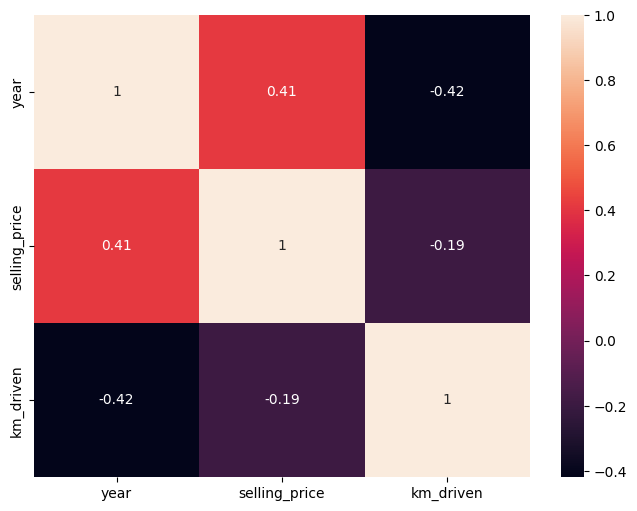

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

**Data Cleaning & Processing**

In [102]:
dfcleaned = df.copy()

In [104]:
dfcleaned.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [105]:
dfcleaned.shape

(4340, 8)

In [106]:
dfcleaned.drop_duplicates(inplace=True)

In [107]:
dfcleaned.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [108]:
dfcleaned.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object


In [109]:
dfcleaned['fuel'].value_counts()

,count
fuel,
Diesel,1800
Petrol,1717
CNG,37
LPG,22
Electric,1


In [110]:
dfcleaned['transmission'].value_counts()

,count
transmission,
Manual,3265
Automatic,312


In [111]:
dfcleaned = pd.get_dummies(dfcleaned,col)
dfcleaned

,year,selling_price,km_driven,km_driven_Ambassador CLASSIC 1500 DSL AC,km_driven_Ambassador Classic 2000 Dsz,km_driven_Ambassador Grand 1800 ISZ MPFI PW CL,km_driven_Audi A4 1.8 TFSI,km_driven_Audi A4 2.0 TDI,km_driven_Audi A4 2.0 TDI 177 Bhp Premium Plus,km_driven_Audi A4 3.0 TDI Quattro,...,km_driven_Dealer,km_driven_Individual,km_driven_Trustmark Dealer,km_driven_Automatic,km_driven_Manual,km_driven_First Owner,km_driven_Fourth & Above Owner,km_driven_Second Owner,km_driven_Test Drive Car,km_driven_Third Owner
0,2007,60000,70000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
1,2007,135000,50000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
2,2012,600000,100000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
3,2017,250000,46000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
4,2014,450000,141000,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,2014,409999,80000,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
4336,2014,409999,80000,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
4337,2009,110000,83000,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
4338,2016,865000,90000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False


**Feature Engineering and Extraction**

In [112]:
dfcleaned

,year,selling_price,km_driven,km_driven_Ambassador CLASSIC 1500 DSL AC,km_driven_Ambassador Classic 2000 Dsz,km_driven_Ambassador Grand 1800 ISZ MPFI PW CL,km_driven_Audi A4 1.8 TFSI,km_driven_Audi A4 2.0 TDI,km_driven_Audi A4 2.0 TDI 177 Bhp Premium Plus,km_driven_Audi A4 3.0 TDI Quattro,...,km_driven_Dealer,km_driven_Individual,km_driven_Trustmark Dealer,km_driven_Automatic,km_driven_Manual,km_driven_First Owner,km_driven_Fourth & Above Owner,km_driven_Second Owner,km_driven_Test Drive Car,km_driven_Third Owner
0,2007,60000,70000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
1,2007,135000,50000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
2,2012,600000,100000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
3,2017,250000,46000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
4,2014,450000,141000,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,2014,409999,80000,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
4336,2014,409999,80000,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
4337,2009,110000,83000,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
4338,2016,865000,90000,False,False,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False


In [119]:
df_cleaned = dfcleaned.astype(int)
df_cleaned

,year,selling_price,km_driven,km_driven_Ambassador CLASSIC 1500 DSL AC,km_driven_Ambassador Classic 2000 Dsz,km_driven_Ambassador Grand 1800 ISZ MPFI PW CL,km_driven_Audi A4 1.8 TFSI,km_driven_Audi A4 2.0 TDI,km_driven_Audi A4 2.0 TDI 177 Bhp Premium Plus,km_driven_Audi A4 3.0 TDI Quattro,...,km_driven_Dealer,km_driven_Individual,km_driven_Trustmark Dealer,km_driven_Automatic,km_driven_Manual,km_driven_First Owner,km_driven_Fourth & Above Owner,km_driven_Second Owner,km_driven_Test Drive Car,km_driven_Third Owner
0,2007,60000,70000,0,0,0,0,0,0,0,...,0,1,0,0,1,1,0,0,0,0
1,2007,135000,50000,0,0,0,0,0,0,0,...,0,1,0,0,1,1,0,0,0,0
2,2012,600000,100000,0,0,0,0,0,0,0,...,0,1,0,0,1,1,0,0,0,0
3,2017,250000,46000,0,0,0,0,0,0,0,...,0,1,0,0,1,1,0,0,0,0
4,2014,450000,141000,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,2014,409999,80000,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
4336,2014,409999,80000,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
4337,2009,110000,83000,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
4338,2016,865000,90000,0,0,0,0,0,0,0,...,0,1,0,0,1,1,0,0,0,0


In [120]:
df_cleaned.columns

Index(['year', 'selling_price', 'km_driven',
       'km_driven_Ambassador CLASSIC 1500 DSL AC',
       'km_driven_Ambassador Classic 2000 Dsz',
       'km_driven_Ambassador Grand 1800 ISZ MPFI PW CL',
       'km_driven_Audi A4 1.8 TFSI', 'km_driven_Audi A4 2.0 TDI',
       'km_driven_Audi A4 2.0 TDI 177 Bhp Premium Plus',
       'km_driven_Audi A4 3.0 TDI Quattro',
       ...
       'km_driven_Dealer', 'km_driven_Individual',
       'km_driven_Trustmark Dealer', 'km_driven_Automatic', 'km_driven_Manual',
       'km_driven_First Owner', 'km_driven_Fourth & Above Owner',
       'km_driven_Second Owner', 'km_driven_Test Drive Car',
       'km_driven_Third Owner'],
      dtype='object', length=1509)

In [125]:
# Split data into training and testing sets
from sklearn.preprocessing import StandardScaler

cols = ["km_driven" , "year"]

scalar = StandardScaler()

df_cleaned[cols] = scalar.fit_transform(df_cleaned[cols])


In [132]:
df_cleaned.columns

Index(['year', 'selling_price', 'km_driven',
       'km_driven_Ambassador CLASSIC 1500 DSL AC',
       'km_driven_Ambassador Classic 2000 Dsz',
       'km_driven_Ambassador Grand 1800 ISZ MPFI PW CL',
       'km_driven_Audi A4 1.8 TFSI', 'km_driven_Audi A4 2.0 TDI',
       'km_driven_Audi A4 2.0 TDI 177 Bhp Premium Plus',
       'km_driven_Audi A4 3.0 TDI Quattro',
       ...
       'km_driven_Dealer', 'km_driven_Individual',
       'km_driven_Trustmark Dealer', 'km_driven_Automatic', 'km_driven_Manual',
       'km_driven_First Owner', 'km_driven_Fourth & Above Owner',
       'km_driven_Second Owner', 'km_driven_Test Drive Car',
       'km_driven_Third Owner'],
      dtype='object', length=1509)

In [139]:
from scipy.stats import pearsonr

selected_features = ["year","km_driven","km_driven_Automatic","km_driven_Manual",'km_driven_Dealer', 'km_driven_Individual',
       'km_driven_Trustmark Dealer', 'km_driven_Automatic', 'km_driven_Manual',
       'km_driven_First Owner', 'km_driven_Fourth & Above Owner',
       'km_driven_Second Owner', 'km_driven_Test Drive Car',
       'km_driven_Third Owner']

corelations = {
    feature: pearsonr(df_cleaned[feature],df_cleaned["selling_price"])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(corelations.items()), columns=['feature','pearsonr correlations'])

correlation_df.sort_values(by='pearsonr correlations',ascending = False)

,feature,pearsonr correlations
2,km_driven_Automatic,0.486269
0,year,0.424260
7,km_driven_First Owner,0.229482
4,km_driven_Dealer,0.175024
6,km_driven_Trustmark Dealer,0.066012
10,km_driven_Test Drive Car,0.065189
8,km_driven_Fourth & Above Owner,-0.084116
11,km_driven_Third Owner,-0.120963
9,km_driven_Second Owner,-0.158960
1,km_driven,-0.187359


In [140]:
final_df = df_cleaned.copy()

## Machine Learning Model: Linear Regression

In [141]:
# Define features (X) and target (y)
X = final_df.drop('selling_price', axis=1)
y = final_df['selling_price']

In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2861, 1508)
X_test shape: (716, 1508)
y_train shape: (2861,)
y_test shape: (716,)


In [143]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [146]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 152208.89
Mean Squared Error (MSE): 154012978670.77
Root Mean Squared Error (RMSE): 392444.87
R-squared (R2): 0.52
